In [ ]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset (1).csv to placement_predict_50k Dataset (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/placement_predict_50k Dataset (1).csv')

print(df.shape)

df.head()

(50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,1,2,NaN,2,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,0,1,0.0,1,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,1,3,1.0,1,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,1,2,1.0,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,2,3,NaN,4,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

print(df['PlacementStatus'].value_counts())

print(df['CGPA_Tier'].value_counts())

Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
dtype: int64
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64
CGPA_Tier
Low     16733
High    16681
Mid     16586
Name: count, dtype: int64


In [ ]:
drop_common = [
    'StudentID',
    'IsAnomaly',
    'Salary Package'
]

categorical_cols = [
    'Gender',
    'City',
    'CollegeTier',
    'Stream',
    'Specialisation',
    'Hostel',
    'HistoryOfBacklogs',
    'ExtraCurricular'
]

numeric_cols = [
    'SGPA_Sem1',
    'SGPA_Sem2',
    'SGPA_Sem3',
    'SGPA_Sem4',
    'SGPA_Sem5',
    'SGPA_Sem6',
    'SGPA_Sem7',
    'SGPA_Sem8',
    'CGPA',
    'AttendancePercent',
    'Internships',
    'Projects',
    'Workshops',
    'Certifications',
    'Publications',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'CodingTestScore',
    'MockInterviewScore'
]

print(len(categorical_cols), 'categorical |', len(numeric_cols), 'numeric')

8 categorical | 19 numeric


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first'
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [ ]:
def evaluate_classifier(
    model,
    X_test,
    y_test,
    class_names=None,
    average='binary'
):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average=average,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average=average,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average=average,
        zero_division=0
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    if average == 'binary' and hasattr(model, "predict_proba"):

        y_proba = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_proba)

        print(f"ROC-AUC  : {auc:.4f}")

        fpr, tpr, _ = roc_curve(y_test, y_proba)

        plt.figure(figsize=(5, 5))
        plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
        plt.plot(
            [0, 1],
            [0, 1],
            linestyle='--',
            color='gray'
        )

        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')

    plt.title('Confusion Matrix')
    plt.colorbar()

    ticks = (
        class_names
        if class_names is not None
        else np.unique(y_test)
    )

    plt.xticks(
        range(len(ticks)),
        ticks,
        rotation=45
    )

    plt.yticks(
        range(len(ticks)),
        ticks
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

In [ ]:
X1 = df[numeric_cols + categorical_cols]

y1 = df['PlacementStatus']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

placement_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

placement_model.fit(X1_train, y1_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SGPA_Sem1', 'SGPA_Sem2',
                                                   'SGPA_Sem3', 'SGPA_Sem4',
                                                   'SGPA_Sem5', 'SGPA_Sem6',
                                                   'SGPA_Sem7', 'SGPA_Sem8',
                                                   'CGPA', 'AttendancePercent',
                                                   'Internships', 'Projects',
                                                   'Workshops',
                                                   'Certifications',
                                                   'Publicati...
                                                   'CodingTestScore',
                                                   'MockInterviewScore']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'City',
                                                   'CollegeTier', 'Stream',
                                                   'Specialisation', 'Hostel',
                                                   'HistoryOfBacklogs',
                                                   'ExtraCurricular'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Accuracy : 0.9201
Precision: 0.9259
Recall   : 0.9548
F1-score : 0.9401
ROC-AUC  : 0.9793


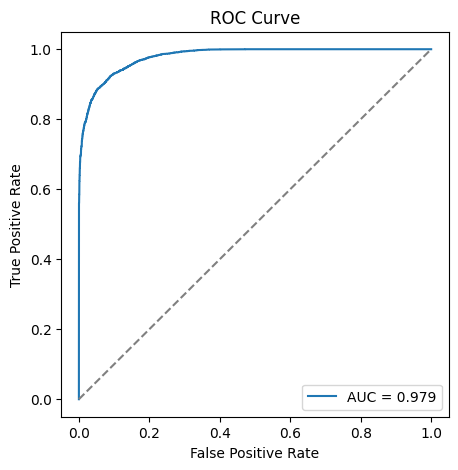

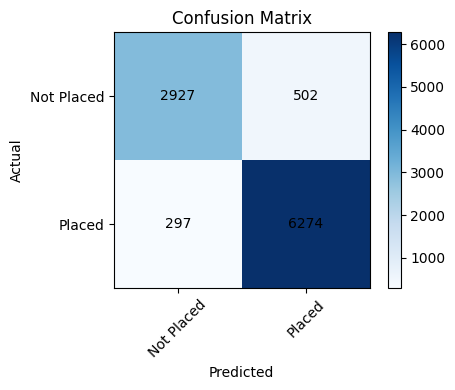


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88      3429
           1       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000



In [ ]:
results_placement = evaluate_classifier(
    placement_model,
    X1_test,
    y1_test,
    class_names=['Not Placed', 'Placed'],
    average='binary'
)

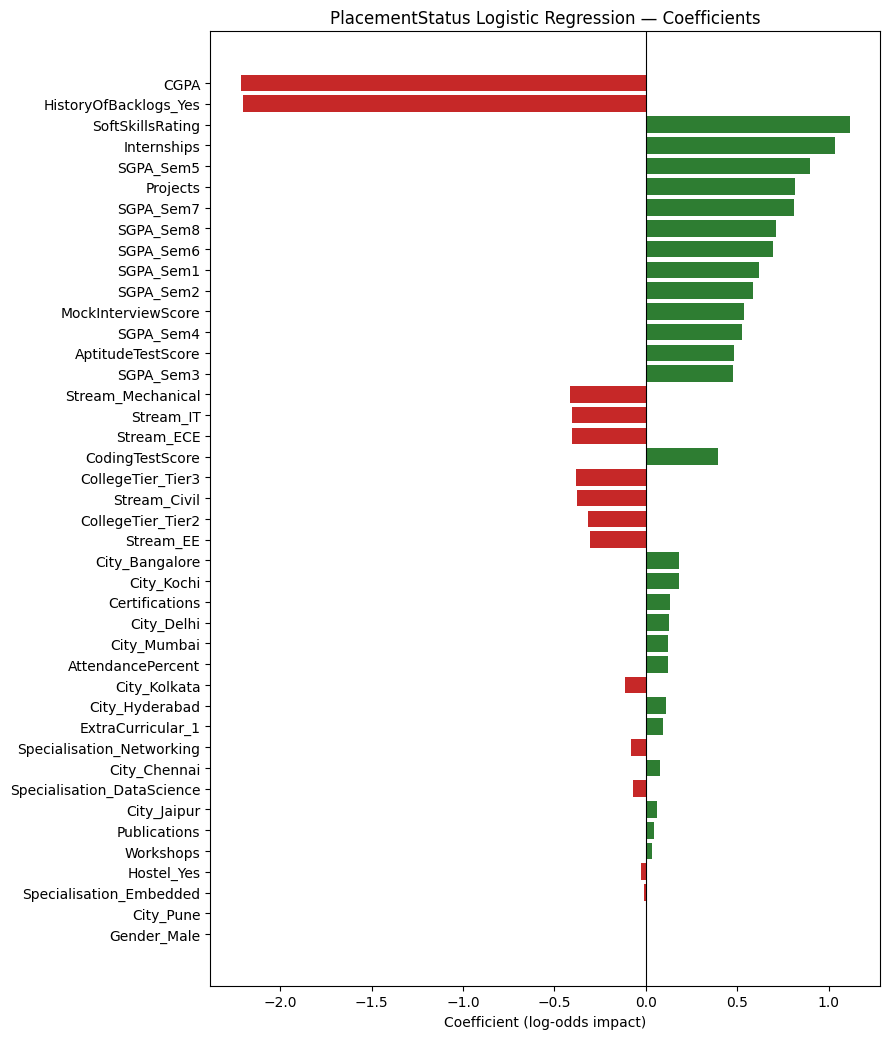

In [ ]:
def get_feature_names(
    preprocessor,
    numeric_cols,
    categorical_cols
):
    ohe = preprocessor.named_transformers_[
        'cat'
    ].named_steps['onehot']

    cat_names = ohe.get_feature_names_out(
        categorical_cols
    )

    return list(numeric_cols) + list(cat_names)


feature_names_1 = get_feature_names(
    placement_model.named_steps['preprocessor'],
    numeric_cols,
    categorical_cols
)

coefs_1 = placement_model.named_steps[
    'classifier'
].coef_[0]

coef_df_1 = pd.DataFrame({
    'feature': feature_names_1,
    'coefficient': coefs_1
})

coef_df_1 = coef_df_1.reindex(
    coef_df_1.coefficient.abs()
    .sort_values(ascending=False)
    .index
)

plt.figure(
    figsize=(9, max(6, len(coef_df_1) * 0.25))
)

colors = [
    '#2E7D32' if c > 0 else '#C62828'
    for c in coef_df_1['coefficient']
]

plt.barh(
    coef_df_1['feature'],
    coef_df_1['coefficient'],
    color=colors
)

plt.gca().invert_yaxis()

plt.axvline(
    0,
    color='black',
    linewidth=0.8
)

plt.xlabel('Coefficient (log-odds impact)')

plt.title(
    'PlacementStatus Logistic Regression — Coefficients'
)

plt.tight_layout()
plt.show()

In [ ]:
numeric_cols_tier = [
    c for c in numeric_cols
    if c != 'CGPA'
]

X2 = df[
    numeric_cols_tier + categorical_cols
]

y2 = df['CGPA_Tier']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

preprocessor_tier = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_cols_tier
        ),
        (
            'cat',
            categorical_transformer,
            categorical_cols
        )
    ]
)

tier_model = Pipeline(steps=[
    (
        'preprocessor',
        preprocessor_tier
    ),
    (
        'classifier',
        LogisticRegression(
            max_iter=2000,
            multi_class='multinomial',
            solver='lbfgs',
            random_state=42
        )
    )
])

tier_model.fit(X2_train, y2_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SGPA_Sem1', 'SGPA_Sem2',
                                                   'SGPA_Sem3', 'SGPA_Sem4',
                                                   'SGPA_Sem5', 'SGPA_Sem6',
                                                   'SGPA_Sem7', 'SGPA_Sem8',
                                                   'AttendancePercent',
                                                   'Internships', 'Projects',
                                                   'Workshops',
                                                   'Certifications',
                                                   'Publications',
                                                   'A...
                                                   'MockInterviewScore']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'City',
                                                   'CollegeTier', 'Stream',
                                                   'Specialisation', 'Hostel',
                                                   'HistoryOfBacklogs',
                                                   'ExtraCurricular'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, multi_class='multinomial',
                                    random_state=42))])

Accuracy : 0.9689
Precision: 0.9689
Recall   : 0.9689
F1-score : 0.9689


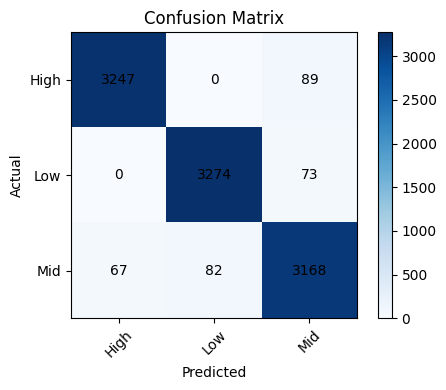


Classification Report:
               precision    recall  f1-score   support

        High       0.98      0.97      0.98      3336
         Low       0.98      0.98      0.98      3347
         Mid       0.95      0.96      0.95      3317

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
class_order = sorted(y2.unique())

results_tier = evaluate_classifier(
    tier_model,
    X2_test,
    y2_test,
    class_names=class_order,
    average='macro'
)

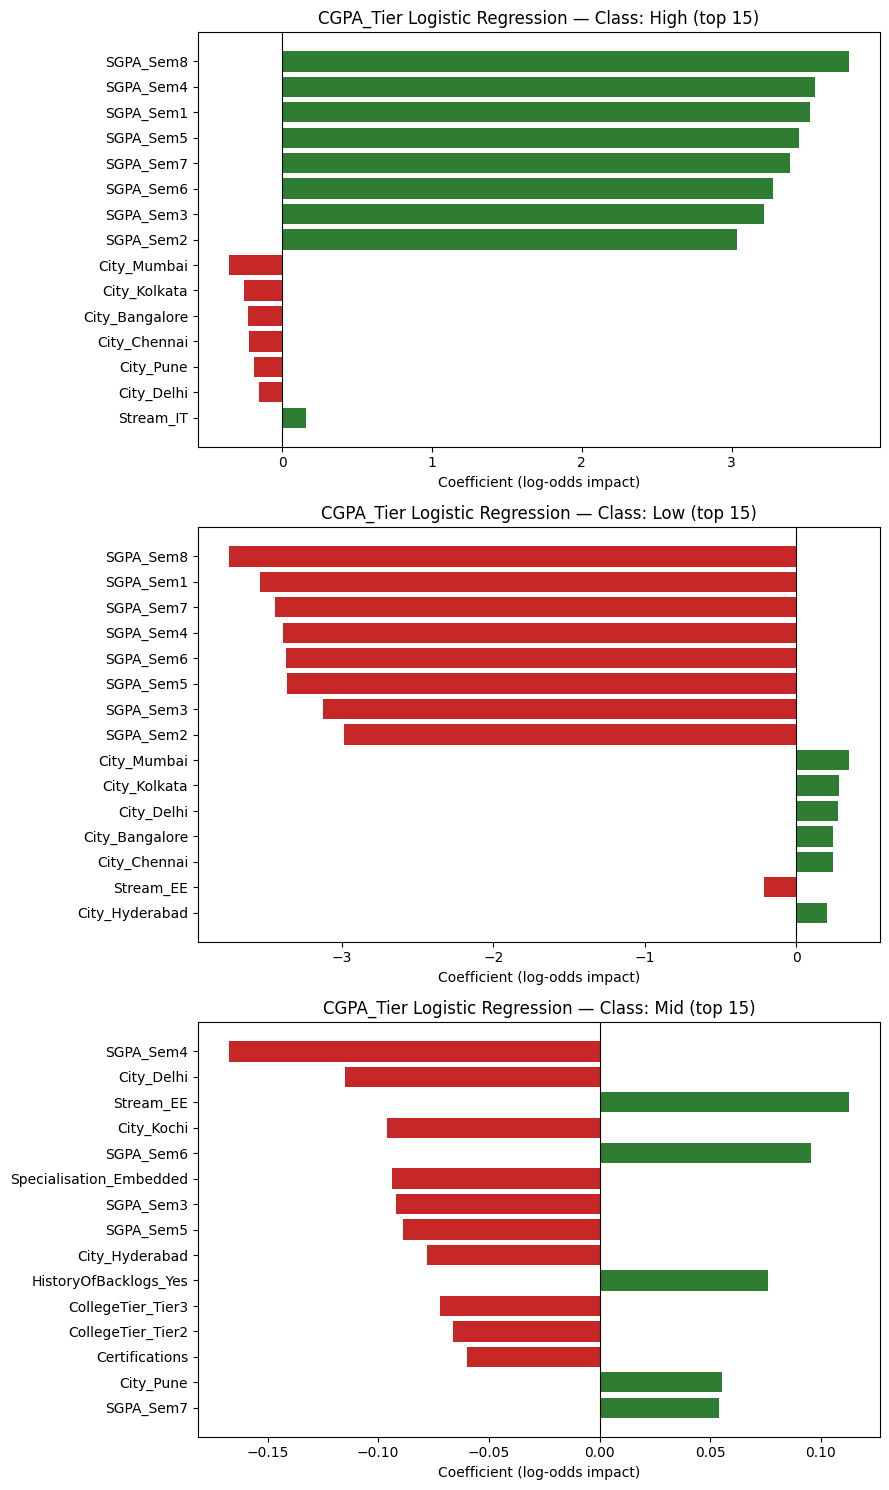

In [ ]:
feature_names_2 = get_feature_names(
    tier_model.named_steps['preprocessor'],
    numeric_cols_tier,
    categorical_cols
)

classes_2 = tier_model.named_steps[
    'classifier'
].classes_

coefs_2 = tier_model.named_steps[
    'classifier'
].coef_

fig, axes = plt.subplots(
    len(classes_2),
    1,
    figsize=(9, 5 * len(classes_2))
)

if len(classes_2) == 1:
    axes = [axes]

for ax, cls, coef_row in zip(
    axes,
    classes_2,
    coefs_2
):

    cdf = pd.DataFrame({
        'feature': feature_names_2,
        'coefficient': coef_row
    })

    cdf = cdf.reindex(
        cdf.coefficient.abs()
        .sort_values(ascending=False)
        .index
    ).head(15)

    colors = [
        '#2E7D32' if c > 0 else '#C62828'
        for c in cdf['coefficient']
    ]

    ax.barh(
        cdf['feature'],
        cdf['coefficient'],
        color=colors
    )

    ax.invert_yaxis()

    ax.axvline(
        0,
        color='black',
        linewidth=0.8
    )

    ax.set_title(
        f'CGPA_Tier Logistic Regression — '
        f'Class: {cls} (top 15)'
    )

    ax.set_xlabel(
        'Coefficient (log-odds impact)'
    )

plt.tight_layout()
plt.show()

In [ ]:
print("=== Model comparison ===")

print(
    "PlacementStatus (binary):",
    results_placement
)

print(
    "CGPA_Tier (multinomial):",
    results_tier
)

=== Model comparison ===
PlacementStatus (binary): {'accuracy': 0.9201, 'precision': 0.9259149940968123, 'recall': 0.9548014000913103, 'f1': 0.9401363602307634}
CGPA_Tier (multinomial): {'accuracy': 0.9689, 'precision': 0.9689000804738352, 'recall': 0.9688635525860202, 'f1': 0.9688764514569419}
